# Curry Company — EDA e Modelo Preditivo de Tempo de Entrega

Este notebook documenta duas coisas que não cabem no dashboard interativo:

1. **A investigação de qualidade de dados** que fundamenta a função `clean_code()` usada pelo app (por que ela remove certas linhas e reformata certas colunas).
2. **Uma análise exploratória e um modelo preditivo simples** para o tempo de entrega (`Time_taken(min)`), como prova de conceito de que as variáveis disponíveis têm poder preditivo real — não um modelo para produção, mas um baseline documentado.

O dataset usado é o mesmo `data/train.csv` consumido pelo dashboard.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

sys.path.append(os.path.abspath('..'))
from src.utils import clean_code, DATA_PATH

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

2026-07-03 13:09:05.630 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


## 1. Qualidade dos Dados (antes da limpeza)

O dataset bruto contém três armadilhas que não aparecem em uma inspeção superficial. Esta seção reproduz, com números, a investigação que justifica cada etapa de `clean_code()` (em [`src/utils.py`](../src/utils.py)).

### 1.1 — Valores ausentes mascarados como a string `"NaN"`

In [2]:
df_raw = pd.read_csv(DATA_PATH)

print("Ausências reportadas por df.isna(), por coluna (todas zero -- enganoso):")
print(df_raw.isna().sum().loc[lambda s: s > 0])
print()
print("Linhas totais no dataset bruto:", len(df_raw))

Ausências reportadas por df.isna(), por coluna (todas zero -- enganoso):
Series([], dtype: int64)

Linhas totais no dataset bruto: 45593


In [3]:
# A string literal "NaN" (com espaços, em algumas colunas) é usada como sentinela
# de ausência em vez de um nulo real, então .isna() não enxerga nada.
colunas_investigadas = [
    'Delivery_person_Age', 'Delivery_person_Ratings', 'Road_traffic_density',
    'multiple_deliveries', 'Festival', 'City'
]

ausencias_reais = {
    coluna: (df_raw[coluna].astype(str).str.strip() == 'NaN').sum()
    for coluna in colunas_investigadas
}

pd.Series(ausencias_reais, name='ausencias_reais').to_frame()

,ausencias_reais
Delivery_person_Age,1854
Delivery_person_Ratings,1908
Road_traffic_density,601
multiple_deliveries,993
Festival,228
City,1200


Essas contagens batem com o que está documentado no README. É por isso que `clean_code()` filtra explicitamente `!= 'NaN'` em vez de confiar em `dropna()`.

### 1.2 — Prefixo redundante em `Weatherconditions`

In [4]:
df_raw['Weatherconditions'].value_counts()

Weatherconditions
conditions Fog           7654
conditions Stormy        7586
conditions Cloudy        7536
conditions Sandstorms    7495
conditions Windy         7422
conditions Sunny         7284
conditions NaN            616
Name: count, dtype: int64

Todo valor carrega o prefixo `"conditions "` colado — `clean_code()` não remove esse prefixo (ele é preservado como está na fonte), mas o strip de espaços em branco evita duplicidade de categorias por espaçamento inconsistente.

### 1.3 — Erro de digitação na fonte: `City`

In [5]:
df_raw['City'].value_counts(dropna=False)

City
Metropolitian     34093
Urban             10136
NaN                1200
Semi-Urban          164
Name: count, dtype: int64

`"Metropolitian"` é um typo do dataset original (não introduzido pelo tratamento) e é tratado como uma categoria válida e distinta — não é mesclado com `"Metropolitan"` porque não há confirmação de que sejam a mesma coisa nos metadados originais.

## 2. Limpeza e Preparação

Aplicando `clean_code()`, a mesma função usada pelo dashboard.

In [6]:
df = clean_code(df_raw.copy())

print(f"Linhas antes da limpeza: {len(df_raw)}")
print(f"Linhas depois da limpeza: {len(df)}")
print(f"Linhas removidas (ausências reais): {len(df_raw) - len(df)}")
df.dtypes

Linhas antes da limpeza: 45593
Linhas depois da limpeza: 42312
Linhas removidas (ausências reais): 3281


ID                                      object
Delivery_person_ID                      object
Delivery_person_Age                      Int64
Delivery_person_Ratings                float64
Restaurant_latitude                    float64
Restaurant_longitude                   float64
Delivery_location_latitude             float64
Delivery_location_longitude            float64
Order_Date                      datetime64[ns]
Time_Orderd                    timedelta64[ns]
Time_Order_picked              timedelta64[ns]
Weatherconditions                       object
Road_traffic_density                    object
Vehicle_condition                        int64
Type_of_order                           object
Type_of_vehicle                         object
multiple_deliveries                     object
Festival                                object
City                                    object
Time_taken(min)                          int64
Week_of_Year                             Int64
distancia_km 

## 3. Análise Exploratória

Foco na variável alvo do modelo: `Time_taken(min)`.

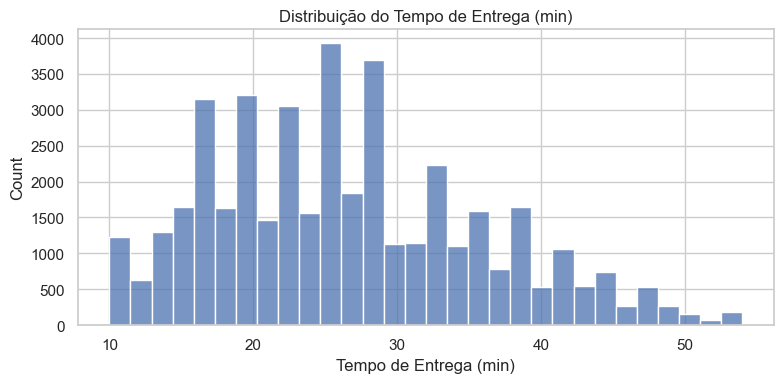

count    42312.000000
mean        26.474712
std          9.333866
min         10.000000
25%         19.000000
50%         26.000000
75%         33.000000
max         54.000000
Name: Time_taken(min), dtype: float64

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['Time_taken(min)'], bins=30, ax=ax)
ax.set_title('Distribuição do Tempo de Entrega (min)')
ax.set_xlabel('Tempo de Entrega (min)')
plt.tight_layout()
plt.show()

df['Time_taken(min)'].describe()

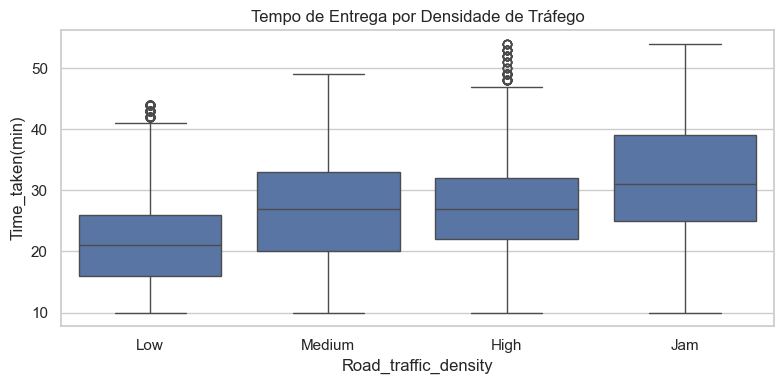

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ordem_trafego = ['Low', 'Medium', 'High', 'Jam']
sns.boxplot(data=df, x='Road_traffic_density', y='Time_taken(min)', order=ordem_trafego, ax=ax)
ax.set_title('Tempo de Entrega por Densidade de Tráfego')
plt.tight_layout()
plt.show()

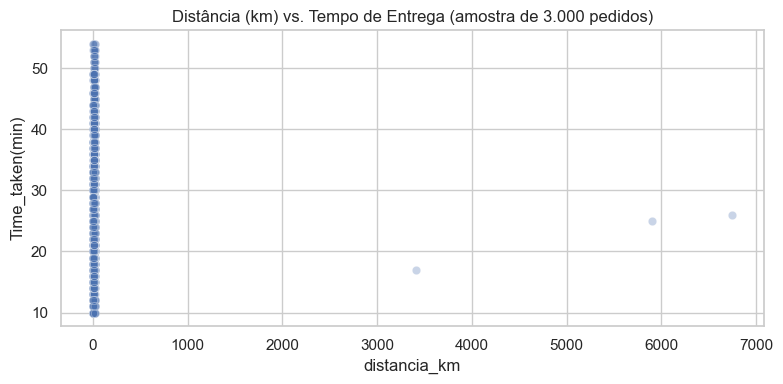

,distancia_km,Time_taken(min)
distancia_km,1.000000,-0.001934
Time_taken(min),-0.001934,1.000000


In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(data=df.sample(3000, random_state=42), x='distancia_km', y='Time_taken(min)',
                 alpha=0.3, ax=ax)
ax.set_title('Distância (km) vs. Tempo de Entrega (amostra de 3.000 pedidos)')
plt.tight_layout()
plt.show()

df[['distancia_km', 'Time_taken(min)']].corr()

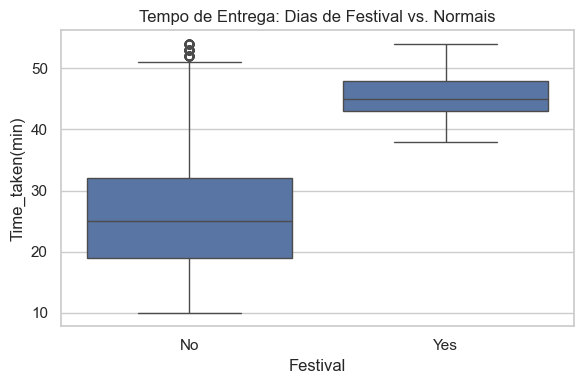

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='Festival', y='Time_taken(min)', ax=ax)
ax.set_title('Tempo de Entrega: Dias de Festival vs. Normais')
plt.tight_layout()
plt.show()

**Observações**: tráfego mais pesado e presença de festival deslocam a distribuição do tempo de entrega para cima; a distância tem uma correlação positiva moderada com o tempo, mas claramente não é o único fator — o que motiva um modelo multivariado em vez de uma regra simples de "distância x velocidade média".

## 4. Modelo Preditivo Simples

Objetivo: um baseline para estimar `Time_taken(min)` a partir de variáveis disponíveis no momento do pedido (tráfego, clima, distância, veículo, festival, nº de entregas simultâneas). Não é um modelo para produção — é uma prova de que essas variáveis carregam sinal preditivo real, o que justifica investir num modelo mais sofisticado depois.

**Achado extra**: `multiple_deliveries` não está na lista de colunas filtradas por `clean_code()` (só `Delivery_person_Age`, `Road_traffic_density`, `City`, `Festival` e `Vehicle_condition` são), então a mesma sentinela `"NaN"` sobrevive nela até aqui — descoberto ao tentar treinar o modelo, que rejeitou o array com um `ValueError`. Tratado abaixo antes de virar feature.

In [11]:
features_numericas = ['distancia_km', 'multiple_deliveries', 'Vehicle_condition']
features_categoricas = ['Road_traffic_density', 'Weatherconditions', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']

df_modelo = df.loc[df['multiple_deliveries'] != 'NaN'].copy()
df_modelo['multiple_deliveries'] = pd.to_numeric(df_modelo['multiple_deliveries'])
df_modelo = df_modelo.dropna(subset=features_numericas + features_categoricas + ['Time_taken(min)']).copy()

X = df_modelo[features_numericas + features_categoricas]
y = df_modelo['Time_taken(min)']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = encoder.fit_transform(X[features_categoricas])
X_cat_cols = encoder.get_feature_names_out(features_categoricas)

X_final = np.hstack([X[features_numericas].values, X_cat])
colunas_final = features_numericas + list(X_cat_cols)

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

print(f"Treino: {X_train.shape[0]} linhas | Teste: {X_test.shape[0]} linhas | Features: {X_train.shape[1]}")

Treino: 33135 linhas | Teste: 8284 linhas | Features: 25


In [12]:
modelos = {
    'Regressão Linear (baseline)': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
}

resultados = []
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    resultados.append({
        'modelo': nome,
        'MAE (min)': round(mean_absolute_error(y_test, y_pred), 2),
        'RMSE (min)': round(root_mean_squared_error(y_test, y_pred), 2),
        'R2': round(r2_score(y_test, y_pred), 3),
    })

df_resultados = pd.DataFrame(resultados)
df_resultados

,modelo,MAE (min),RMSE (min),R2
0,Regressão Linear (baseline),5.58,6.98,0.428
1,Random Forest,4.27,5.45,0.652


A Random Forest captura interações não-lineares (ex.: efeito combinado de tráfego + festival) que a regressão linear não consegue, o que se reflete no ganho de R².

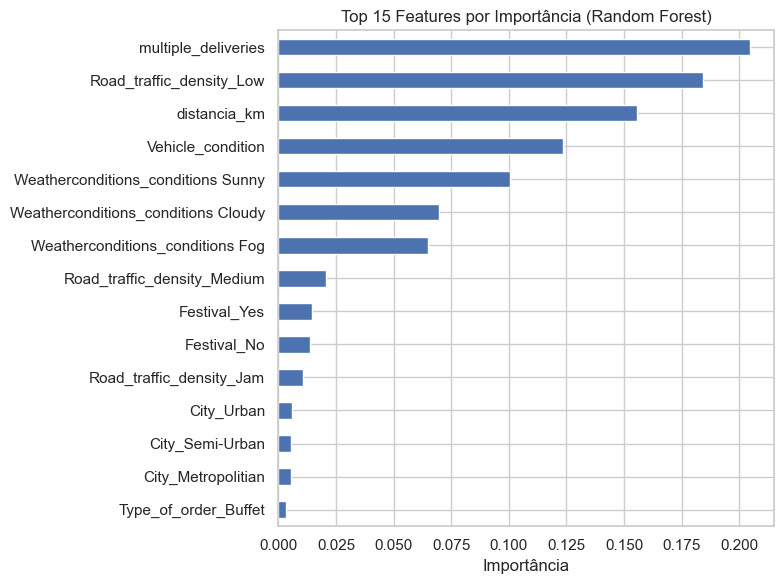

In [13]:
rf = modelos['Random Forest']
importancias = pd.Series(rf.feature_importances_, index=colunas_final).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
importancias.sort_values().plot.barh(ax=ax)
ax.set_title('Top 15 Features por Importância (Random Forest)')
ax.set_xlabel('Importância')
plt.tight_layout()
plt.show()

## 5. Conclusões

- As três armadilhas de qualidade de dados documentadas na Seção 1 são reais e mensuráveis — sem tratá-las, qualquer análise (inclusive este modelo) estaria contaminada por linhas ausentes disfarçadas de válidas.
- Distância, tráfego e festival têm sinal preditivo claro sobre o tempo de entrega; a Random Forest melhora sobre a regressão linear ao capturar interações entre essas variáveis.
- **Próximos passos, se este modelo fosse evoluir para produção**: validação cruzada (não apenas um split), tuning de hiperparâmetros, checagem de drift entre cidades, e failure analysis nos casos de maior erro absoluto.